In [1]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import json
import string
import Basic_functions as bf  #Homemade script.
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colormaps

from nltk import word_tokenize, trigrams
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

from scipy.optimize import curve_fit
from scipy.stats import chisquare, t
from scipy import sparse

import torch
import torch.nn as nn
import torch.optim as optim

###################################################

#https://gist.github.com/berteltorp/0cf8a0c7afea7f25ed754f24cfc2467b Stopords liste
stopwords_danish = np.genfromtxt(r"txt_files\\stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

print('Packages loaded')

Packages loaded


<h1> Importing the files.</h1>
for 36000 files, takes roughly 7 minuttes

In [3]:
#test = open("Speeches\A._Bartholdy_Møllers_prædiken_1._søndag_efter_paske.txt", "r", encoding="utf-8").read().strip()

def import_txt_files_to_array(folder_path):
    txt_files_content = []
    #txt_year          = []
    #txt_sermon        = []
    Files_read = 0
    folder_read = 0
    
    for i in folder_path:
        for filename in os.listdir(i): #folder_path):
            if filename.endswith('.txt'):
                Files_read = Files_read + 1
                file_path = os.path.join(i, filename) #folder_path, filename)
                
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        
                        content = file.read()

                        #if "talegenre: prædiken" not in content.lower():
                        #    txt_sermon.append(0)
                        #else:
                        #    txt_sermon.append(1)
                        
                        # Split at the first occurrence of "\n\n\n" and take the part after it
                        parts = content.split('\n\n', 1)
                        if len(parts) > 1:
                            text_after_marker = parts[1]
                        else:
                            text_after_marker = content  # Fallback if "\n\n\n" not found
    
                        # Replace escaped newlines (\\n) with spaces, then remove all newlines
                        text_after_marker = text_after_marker.replace('\\n', ' ').replace('\n', ' ')
    
                        # Convert to lowercase, keep letters (including æøå), spaces, and remove ellipses
                        cleaned_text = re.sub(r'[^a-zA-ZæøåÆØÅ\s]', '', text_after_marker.lower())
                        cleaned_text = cleaned_text.replace("'", "")
                        cleaned_text = cleaned_text.replace('...', '')  # Remove ellipses
    
                        # Remove extra spaces (e.g., multiple spaces)
                        cleaned_text = ' '.join(cleaned_text.split())
    
                        txt_files_content.append(cleaned_text)
    
    
                        ############################################
    
                        #year_part = content.split('\n', 2)
                        #year_after_marker = (year_part[1].split('-',1))[0]
                        #cleaned_year = year_after_marker.replace('Date: ', "")
                        #try:
                        #    txt_year.append(float(cleaned_year))
                        #except:
                        #    txt_year.append(0)
                        
                        print(f'Folders read: {folder_read}, files read: {Files_read}', end = '\r')
                        
                except Exception as e:
                    print(f"Error reading {filename}: {e}")
                
    print('\n','Files read:', Files_read)

    return  (pd.DataFrame(txt_files_content, columns = ['text'])
            #pd.DataFrame(txt_year, columns = ['year']),
            #pd.DataFrame(txt_sermon, columns = ['sermon'])
            #pd.DataFrame(extracted_texts, columns = ['In Party'])
            )                              

# Example usage:

start = time.time()

folder_path = [r'../ML2026_Files/Speeches'] #[r'Speeches', r'articles', r'Articles_18']  # Replace with your folder path
df_text = import_txt_files_to_array(folder_path) 
#df, df_year, df_sermon = import_txt_files_to_array(folder_path) 

stop = time.time()
print(f'done, time taken {(stop-start)/60:3f} minuttes' )


#skip = test.find('\n\n\n')
#Raw_test = test[skip:].lower()

#nltk.download('all')


Folders read: 0, files read: 4753
 Files read: 4753
done, time taken 1.560890 minuttes


In [5]:

df_labels = pd.read_csv(r'Data_files/labels_speech.txt',
                        na_values=['nan'],
                        sep = ";",
                        encoding='latin1',
                        header=None,
                        names = ['year', 'sermon', 'party', '?', 'LIX'])

df_labels

,year,sermon,party,?,LIX
0,1942.185845,0,nan,nan,41.674749
1,1945.355251,1,nan,nan,36.583556
2,1944.721461,1,nan,nan,55.123771
3,1945.412785,1,nan,nan,31.591425
4,2025.557534,0,nan,nan,23.361107
...,...,...,...,...,...
4748,2023.027397,0,nan,nan,24.398955
4749,2024.890868,0,nan,nan,58.784014
4750,2022.904566,0,nan,nan,52.739534
4751,2023.032877,0,nan,nan,37.735267


<h1> Preprocessing the files</h1>
takes roughly 192.493180 seconds

In [6]:
def preprocess(text, min_word_length=3, max_word_length=30):
    
    stemmer = SnowballStemmer(language='danish')
    
    tokens = word_tokenize(text, language = 'danish', preserve_line=False)

    tokens = [
        word for word in tokens
        if (word.isalpha() and
            word not in string.punctuation and
            min_word_length <= len(word) <= max_word_length)
    ]
    
    tokens = [word for word in tokens if word.isalpha() and word not in extended_stopwords]
    
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

####################################

start = time.time()

df_clean = pd.DataFrame({
    'text': df_text['text'].apply(preprocess),
    'length': df_text['text'].str.len(),
    'sermon': df_labels['sermon'],
    'LIX': df_labels['LIX'].astype(float),
    'year': df_labels['year'].astype(float)
})

    
stop = time.time()

print(f'Time preprocessing: {(stop-start)/60:3f} minuttes')

Time preprocessing: 1.535746 minuttes


In [272]:
df_clean['text']

0       landsmænd dansk student fædreland skyld udret ...
1       udpræg centralt skøn evangelium kristus saml f...
2       syndsforlad naad fortælling jesu mød synderind...
3       ord indehold her forjæt jesus gav discipl foru...
4       god livsråd grønland fremtid bær ansvar ældr g...
                              ...                        
4748    thank much dont know say heart jumping uhørbar...
4749    excellenci distinguis delegat partn three deca...
4750    toward green reading european chart local self...
4751    ret uddan børn sær pig vigt ret verdenssamfund...
4752    eupolitik vigt engag sund demokrati valg juni ...
Name: text, Length: 4753, dtype: object

In [273]:
print(df_clean['text'], '\n\n')
print(df_text['text'])

0       landsmænd dansk student fædreland skyld udret ...
1       udpræg centralt skøn evangelium kristus saml f...
2       syndsforlad naad fortælling jesu mød synderind...
3       ord indehold her forjæt jesus gav discipl foru...
4       god livsråd grønland fremtid bær ansvar ældr g...
                              ...                        
4748    thank much dont know say heart jumping uhørbar...
4749    excellenci distinguis delegat partn three deca...
4750    toward green reading european chart local self...
4751    ret uddan børn sær pig vigt ret verdenssamfund...
4752    eupolitik vigt engag sund demokrati valg juni ...
Name: text, Length: 4753, dtype: object 


0       landsmænd og danske studenter sit fædreland sk...
1       der er noget udpræget centralt over dette skøn...
2       syndsforladelsens naade med fortællingen om je...
3       disse ord indeholder en herlig forjættelse som...
4       ti gode livsråd du er grønlands fremtid men du...
                             

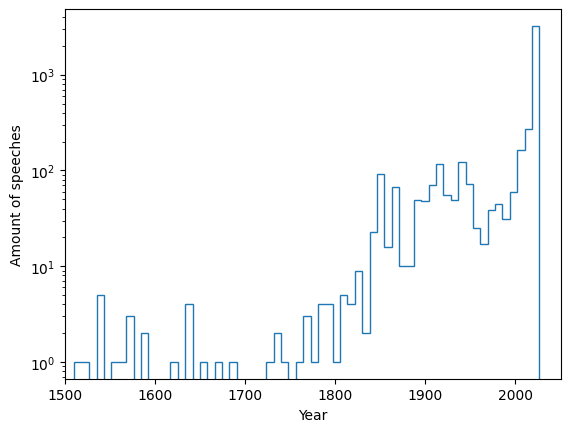

In [274]:
plt.hist(df_clean['year'], bins = 300, histtype = 'step')
plt.yscale('log')
plt.xlim(1500,2050)
plt.xlabel('Year')
plt.ylabel('Amount of speeches')
plt.show()

<h1> Embedding the data</h1>
TF_IDF turns the words into a sparse matrix, weighing the words. Biased by text length, though.

In [7]:
from scipy.sparse import hstack, csr_matrix


vectorizer = TfidfVectorizer(use_idf=True, min_df=25, max_df=0.8, lowercase=True, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
#Term Frequency-Inverse Document Frequency)

#Word2vec is better https://www.geeksforgeeks.org/python/python-word-embedding-using-word2vec/

X_lix = csr_matrix(df_clean[['LIX']].astype(float).values)
X_len = csr_matrix(df_clean[['length']].astype(float).values)
#X_sermon = csr_matrix(df_clean[['sermon']].astype(float).values)
X_text = (vectorizer.fit_transform(df_clean['text'])).astype(np.float32)

X = X_text #hstack([X_text, X_lix, X_len]) #,X_sermon])
y = df_clean['year']
print(f"Sparsity: {X_text.nnz / np.prod(X_text.shape):.3f}")
print("TF-IDF matrix shape:", X.shape) # 174594 words is too much >:( Stemming improved to 112273, removing punctuation and short words: 111767

Sparsity: 0.035
TF-IDF matrix shape: (4753, 7327)


In [57]:
vectorizer.get_feature_names_out()

np.where(vectorizer.get_feature_names_out() == 'gud')

(array([2458]),)

In [19]:
# Save the TF-IDF matrix to a file
sparse.save_npz("tfidf_NLTK_Speeches.npz", X_text)

# Save the feature names (vocabulary) separately
with open("tfidf_NLTK_Speeches_Features.json", "w") as f:
    json.dump(vectorizer.get_feature_names_out().tolist(), f)

print("TF-IDF matrix and features saved successfully!")

TF-IDF matrix and features saved successfully!


<h1> Dimensionality reduction</h1>

In [15]:
svd = TruncatedSVD(n_components=2,
             algorithm='randomized',
             n_iter=10,
             n_oversamples=100,
             power_iteration_normalizer='auto',
             random_state=42,
             tol=1.0)

start = time.time()

X_LSA = svd.fit_transform(X)
print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())
print(svd.singular_values_)

stop = time.time()
print(f'Done in {stop-start:3f} seconds', '\n')

[0.00883841 0.02980662]
0.038645037
[18.407377 11.583035]
Done in 1.861765 seconds 



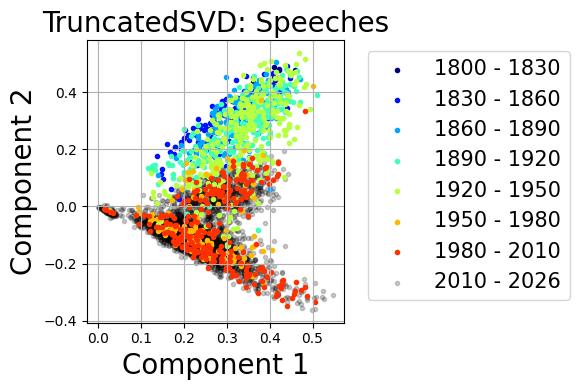

In [21]:
step = 30
intervals = np.arange(1800,2050,step)
intervals[-1] = 2026

try:
    # Create cutoffs column
    df_clean['cutoffs'] = pd.cut(
        df_clean['year'],
        intervals,
        labels=intervals[:-1],
        right=False
    )

    # Verify the column was created
    if 'cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    
    plt.figure(figsize=(6, 4), )
    final_cut = df_clean['cutoffs'].cat.categories[-1]
    colors = cm.jet(np.linspace(0, 1, len(df_clean['cutoffs'].cat.categories)))

    plt.scatter(
        X_LSA[df_clean['cutoffs'] == final_cut, 0],
        X_LSA[df_clean['cutoffs'] == final_cut, 1],
        marker='.',
        label=f'{str(final_cut)} - {str(2026)}',
        alpha=0.2,
        color= 'black'#colors[-1]  # Last color in the jet colormap
    )

    for i, cutoff in enumerate(df_clean['cutoffs'].cat.categories[:-1]):
        subX_LSA = X_LSA[df_clean['cutoffs'] == cutoff, :]
        plt.scatter(
            subX_LSA[:,0],
            subX_LSA[:,1],
            marker='.',
            label=f'{str(cutoff)} - {str(cutoff + step)}',
            alpha=1,
            color=colors[i]  # Use corresponding color from the colormap
        )


    plt.title('TruncatedSVD: Speeches', fontsize=20)
    plt.gca().set_xlabel('Component 1', fontsize=20)
    plt.gca().set_ylabel('Component 2', fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [1,2,3,4,5,6,7,0]

    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], 
               bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 15)
    plt.tight_layout()
    plt.grid()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

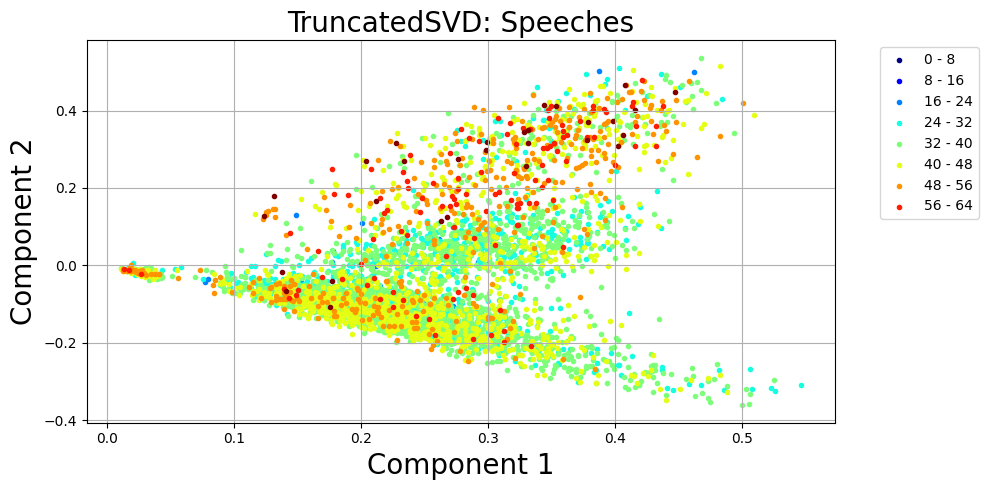

In [25]:
step = 8
intervals_LIX = np.arange(0,80,step)

try:
    # Create cutoffs column
    df_clean['LIX_cutoffs'] = pd.cut(
        df_clean['LIX'],
        intervals_LIX,
        labels=intervals_LIX[:-1],
        right=False
    )

    # Verify the column was created
    if 'LIX_cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    
    plt.figure(figsize=(10, 5), )
    final_cut = df_clean['LIX_cutoffs'].cat.categories[-1]
    colors = cm.jet(np.linspace(0, 1, len(df_clean['LIX_cutoffs'].cat.categories)))

    for i, cutoff in enumerate(df_clean['LIX_cutoffs'].cat.categories):
        subX_LSA = X_LSA[df_clean['LIX_cutoffs'] == cutoff, :]
        plt.scatter(
            subX_LSA[:,0],
            subX_LSA[:,1],
            marker='.',
            label=f'{str(cutoff)} - {str(cutoff + step)}',
            alpha=1,
            color=colors[i]  # Use corresponding color from the colormap
        )


    plt.title('TruncatedSVD: Speeches', fontsize=20)
    plt.gca().set_xlabel('Component 1', fontsize=20)
    plt.gca().set_ylabel('Component 2', fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [0,1,2,3,4,5,6,7]

    
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

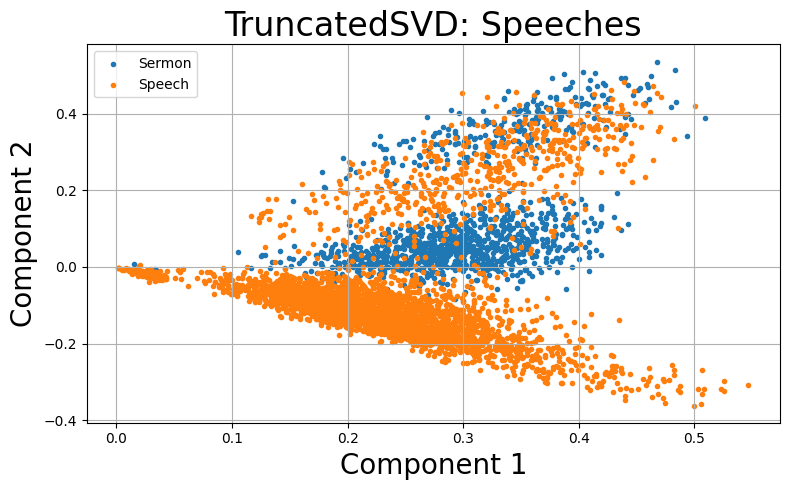

In [27]:
is_serm = df_labels['sermon'].values[:]
plt.figure(figsize=(8, 5))
plt.scatter(X_LSA[ is_serm == 1,0], X_LSA[is_serm == 1,1], marker = '.', label = 'Sermon')
plt.scatter(X_LSA[ is_serm == 0,0], X_LSA[is_serm == 0,1], marker = '.', label = 'Speech')
#plt.scatter(X_LSA[:,0], X_LSA[:,1],marker = '.', c = df_sermon.values, alpha=1)
plt.title('TruncatedSVD: Speeches', fontsize=24)
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

[2.95648331 2.20692204 1.64630213]


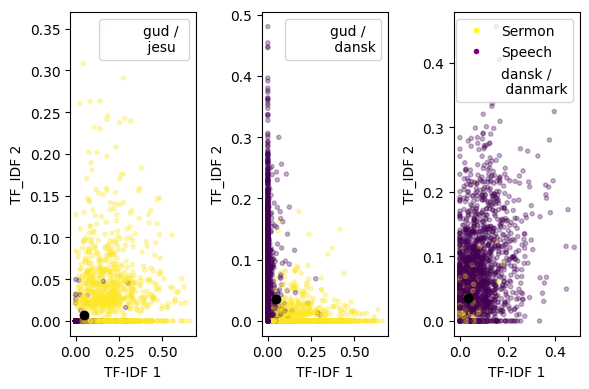

In [29]:
print(vectorizer.idf_[[3100,2458,1006]]) #[2458]
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
test = tfidf_df[['gud','jesu', 'dansk', 'danmark']].values
ifSermon = df_clean['sermon'].values


fig, ax = plt.subplots(1,3, figsize = (6,4))
color = 'blue'
ax[0].scatter(test[:,0], test[:,1], marker = '.', alpha = 0.3, c = ifSermon)
ax[0].scatter(np.mean(test[:,0]), np.mean(test[:,1]), color = 'black')
ax[0].plot([],[], '.',  color = 'white', label = 'gud / \n jesu')
ax[1].scatter(test[:,0], test[:,2], marker = '.', alpha = 0.3, c = ifSermon)
ax[1].scatter(np.mean(test[:,0]), np.mean(test[:,2]), color = 'black')
ax[1].plot([],[], '.', color = 'white', label = 'gud / \n dansk')
ax[2].scatter(test[:,2], test[:,3], marker = '.', alpha = 0.3, c = ifSermon)
ax[2].scatter(np.mean(test[:,2]), np.mean(test[:,3]), color = 'black')
ax[2].plot([],[], '.', c = 'yellow',label = 'Sermon')
ax[2].plot([],[], '.', color = 'purple',label = 'Speech')
ax[2].plot([],[], '.', color = 'white', label = 'dansk / \n danmark')
for i in range(3):
    ax[i].legend()
    ax[i].set_xlabel('TF-IDF 1')
    ax[i].set_ylabel('TF_IDF 2')
    
plt.tight_layout()
plt.show()


<h2> SVD co-ocurance matrix</h2>

In [29]:
svd = TruncatedSVD(n_components=20,
             algorithm='randomized',
             n_iter=20,
             n_oversamples=500,
             power_iteration_normalizer='auto',
             random_state=42,
             tol=1.0)

start = time.time()

X_LSA = svd.fit_transform(X)
print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())
print(svd.singular_values_)

stop = time.time()
print(f'Done in {stop-start:3f} seconds', '\n')

[0.00883842 0.02980661 0.02375114 0.01091315 0.00831533 0.00745488
 0.00679239 0.00513832 0.00485233 0.00454977 0.00435708 0.00426493
 0.00395226 0.00375215 0.00359763 0.00345606 0.00343624 0.00338605
 0.00328852 0.00326252]
0.14716579
[18.407377  11.58303   10.2809925  6.9709024  6.1840596  5.770738
  5.498488   4.786559   4.647385   4.5001774  4.403717   4.357145
  4.1954794  4.0863237  4.002472   3.92625    3.9120104  3.8863916
  3.8257911  3.8118122]
Done in 43.686135 seconds 



Done! Taken 0.780743 seconds


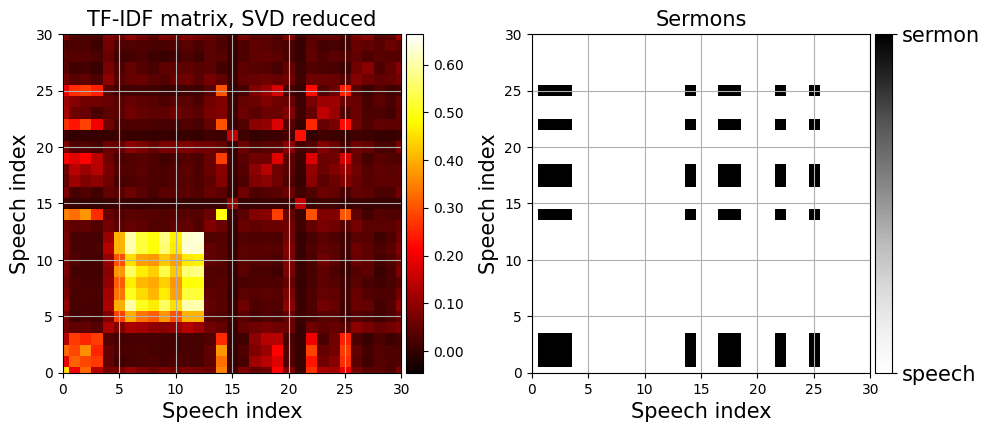

In [31]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, (ax1,ax2) = plt.subplots(1,2, figsize = (10,12))
Sermon_matrix =  np.outer(df_clean['sermon'].values, df_clean['sermon'].values)
start = time.time()
Co_matrix = X_LSA @ X_LSA.T
ax1.set_title('TF-IDF matrix, SVD reduced', fontsize = 15)
im1 = ax1.imshow(Co_matrix, cmap= 'hot')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes('right', size='5%', pad=0.05)
cbar1 = plt.colorbar(im1, cax=cax1, format="%.2f")
ax1.set_xlabel('Speech index', fontsize = 15)
ax1.set_ylabel('Speech index', fontsize = 15)
ax1.grid()
ax1.set_xlim(0,30)
ax1.set_ylim(0,30)
#ax1.set_colorbar()

im2 = ax2.imshow(Sermon_matrix, cmap = 'Greys')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='5%', pad=0.05)
cbar2 = plt.colorbar(im2, cax=cax2, format="%.2f")
cbar2.set_ticks(ticks=[1, 0],labels = ['sermon', 'speech'], fontsize = 15)
ax2.set_title('Sermons', fontsize = 15)
ax2.set_xlabel('Speech index', fontsize = 15)
ax2.set_ylabel('Speech index', fontsize = 15)
ax2.set_xlim(0,30)
ax2.set_ylim(0,30)
ax2.grid()
#ax2.set_colorbar()
plt.tight_layout()
plt.show
stop = time.time()

print(f'Done! Taken {stop - start:3f} seconds')

<h2> UMAP dim reduction</h2>

In [33]:
import umap

reducer = umap.UMAP(n_neighbors= 30, min_dist= 0.0)

embedding = reducer.fit_transform(X)

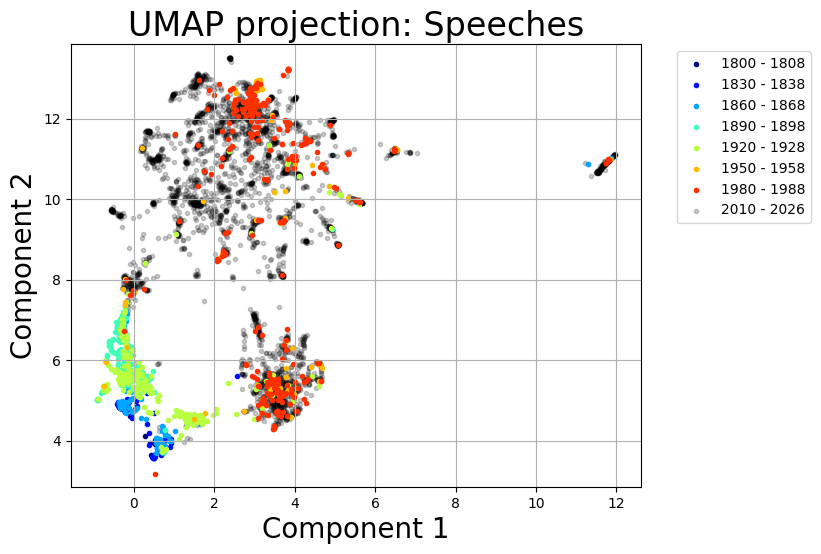

In [34]:
plt.figure(figsize = (8,5))
final_cut = df_clean['cutoffs'].cat.categories[-1]
colors = cm.jet(np.linspace(0, 1, len(df_clean['cutoffs'].cat.categories)))

plt.scatter(
        embedding[df_clean['cutoffs'] == final_cut, 0],
        embedding[df_clean['cutoffs'] == final_cut, 1],
        marker='.',
        label=f'{str(final_cut)} - {str(2026)}',
        alpha=0.2,
        color='black' #colors[-1]  # Last color in the jet colormap
    )

for i, cutoff in enumerate(df_clean['cutoffs'].cat.categories[:-1]):
    subembedding = embedding[df_clean['cutoffs'] == cutoff, :]
    plt.scatter(
        subembedding[:,0],
        subembedding[:,1],
        marker='.',
        label=f'{str(cutoff)} - {str(cutoff + step)}',
        alpha=1,
        color=colors[i]  # Use corresponding color from the colormap
    )

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,2,3,4,5,6,7,0]

plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection: Speeches', fontsize=24);
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
plt.grid()
plt.show()

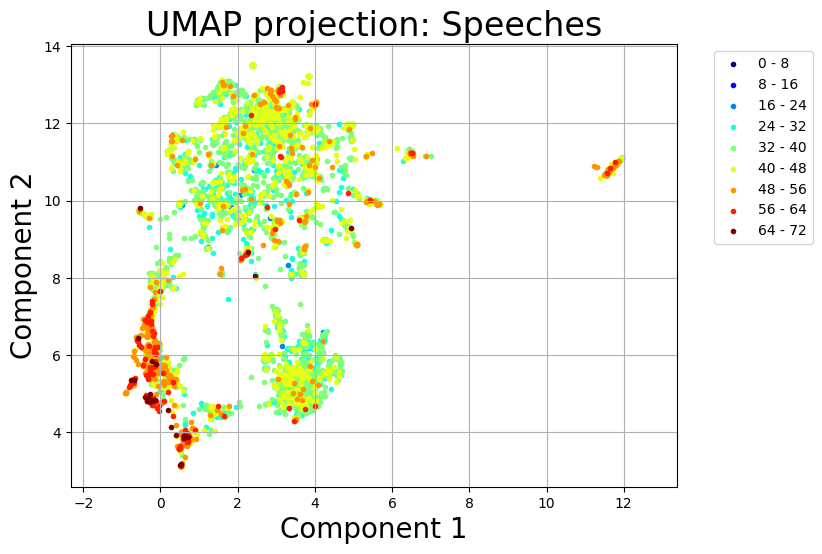

In [37]:
plt.figure(figsize = (8,5))
colors = cm.jet(np.linspace(0, 1, len(df_clean['LIX_cutoffs'].cat.categories)))

for i, cutoff in enumerate(df_clean['LIX_cutoffs'].cat.categories):
    subembedding = embedding[df_clean['LIX_cutoffs'] == cutoff, :]
    plt.scatter(
        subembedding[:,0],
        subembedding[:,1],
        marker='.',
        label=f'{str(cutoff)} - {str(cutoff + step)}',
        alpha=1,
        color=colors[i]  # Use corresponding color from the colormap
    )

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,2,3,4,5,6,7,8]

plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection: Speeches', fontsize=24);
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
plt.grid()
plt.show()

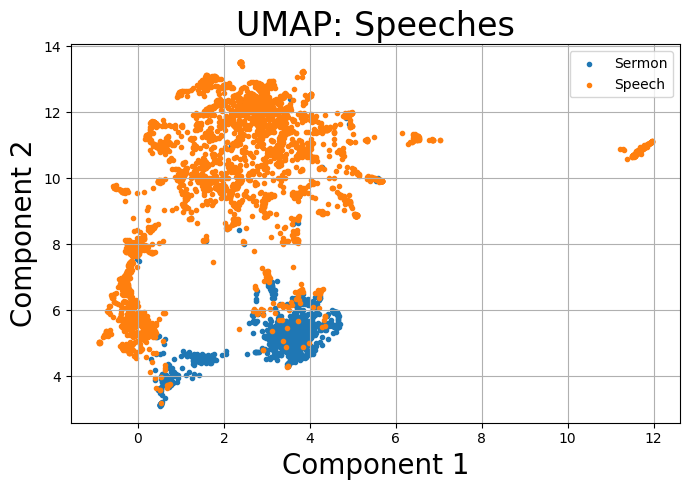

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(embedding[ is_serm == 1,0], embedding[is_serm == 1,1], marker = '.', label = 'Sermon')
plt.scatter(embedding[ is_serm == 0,0], embedding[is_serm == 0,1], marker = '.', label = 'Speech')
#plt.scatter(X_LSA[:,0], X_LSA[:,1],marker = '.', c = df_sermon.values, alpha=1)
plt.title('UMAP: Speeches', fontsize=24)
plt.xlabel('Component 1', fontsize=20)
plt.ylabel('Component 2', fontsize=20)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
#plt.scatter(embedding[:,0], embedding[:,1], c = df_labels['sermon'].values)

<h1>XGboost model training</h1>

In [41]:
#svd = TruncatedSVD(n_components=1000,
#             algorithm='randomized',
#             n_iter=20,
#             n_oversamples=200,
#             power_iteration_normalizer='auto',
#             random_state=42,
#             tol=0.0)
#X_reduced = svd.fit_transform(X)

#reducerUmap = umap.UMAP(n_components = 250, n_neighbors= 30, min_dist= 0.0)

#X_reduced = reducerUmap.fit_transform(X)



X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print('Done')

Done


In [43]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
print('running xgboost version:', xgb.__version__)


model = xgb.XGBRegressor(objective='reg:squarederror',
                         eval_metric = 'rmse',
                         importance_type="weight",
                         n_estimators=200,
                         learning_rate=0.29,
                         max_depth = 11,
                         reg_alpha = 0.7,
                         reg_lambda = 0.82,
                         gamma = 0.63,
                         subsample = 0.93,
                         n_jobs = 1,
                         tree_method = 'hist',
                         early_stopping_rounds = 60,
                         grow_policy = 'lossguide',
                         max_bin = 128,
                         random_state=42)
#min_child_weight = 3,

start = time.time()

evalset = [(X_train, y_train), (X_eval,y_eval)]

model.fit(X_train, y_train, eval_set= evalset, verbose=0)

stop = time.time()
print(f'Training time: {stop - start:3f} seconds')

y_pred = model.predict(X_eval)

rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

running xgboost version: 3.0.0
Training time: 110.171883 seconds
RMSE: 34.581
R²: 0.626


In [45]:
y_pred_test = model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f'RMSE test: {rmse_test:.3f}')
print(f'R² test: {r2_test:.3f}')

RMSE test: 125.376
R² test: -0.343


In [468]:
#model.save_model('model.bin')

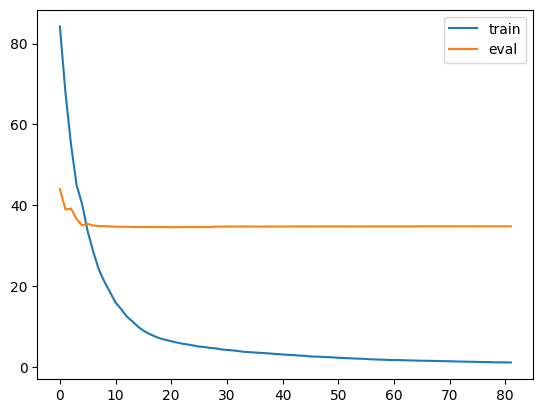

In [47]:
# retrieve performance metrics
results = model.evals_result()

# plot learning curves
plt.plot(results['validation_0']['rmse'], label='train')
plt.plot(results['validation_1']['rmse'], label='eval')
# show the legend
plt.legend()
# show the plot
plt.show()

In [516]:
# Retrieve the "gain" feature importance scores
importance_scores = model.feature_importances_

# Print the feature importance scores along with feature names
Importance_labels = np.argsort(importance_scores)[-32:]
Importance_labels = Importance_labels[ (Importance_labels != 7328) & (Importance_labels != 7327)]
print(vectorizer.get_feature_names_out()[Importance_labels])
#print(importance_scores[Importance_labels])
#for feature, score in zip(vectorizer.get_feature_names_out(), importance_scores):
#    print(f"{feature}: {score}")

['betyd' 'lev' 'liv' 'grund' 'står' 'aabenbar' 'danmark' 'tak' 'berøm'
 'begynd' 'alvor' 'adskil' 'bedr' 'realitet' 'ansvar' 'accept' 'tal'
 'aabn' 'løsriv' 'adgang' 'bedst' 'fortjenest' 'almind' 'dansk' 'absolut'
 'blev' 'aand' 'arbejd' 'aar' 'afgør']


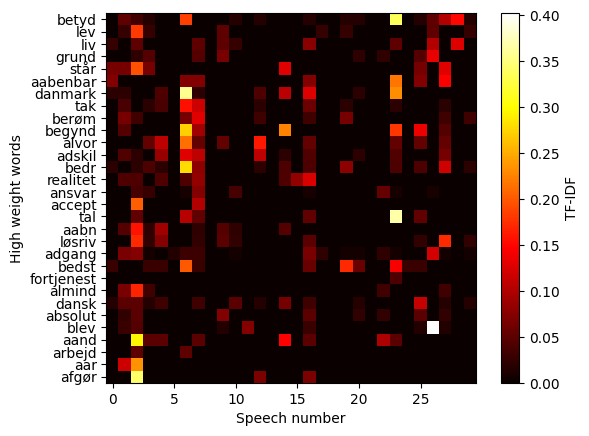

In [510]:
#https://hackernoon.com/document-term-matrix-in-nlp-count-and-tf-idf-scores-explained
vectorizer.get_feature_names_out()[Importance_labels]
Axis_values = vectorizer.get_feature_names_out()[Importance_labels]
Occ_matrix = X[:,Importance_labels].todense()[0:30,:]
y_axis = np.arange(30)
#plt.cmap('heat')
plt.imshow(Occ_matrix, cmap = 'hot')
plt.yticks(y_axis, Axis_values)
plt.xlabel('Speech document')
plt.ylabel('High weight words')
plt.xlabel('Speech number')
plt.colorbar(label = 'TF-IDF')
plt.show()

In [51]:
from sklearn.cluster import KMeans
N_cluster = 5
c_cluster = KMeans(n_clusters=N_cluster,
                   n_init = "auto"
                  ).fit_predict(list(zip(y_pred,y_eval)))
#print(c_cluster)

Mass_means = []
for i in range(0,N_cluster):
    mean_year = np.array([np.mean(y_pred[c_cluster == i])]) #, np.mean(y_eval[c_cluster == i])])
    Mass_means.append(mean_year,)

Mass_means = np.sort(Mass_means, axis = 0)

print(Mass_means)

Intervals_xgb = []
for j in range(N_cluster-1):
    Intervals_xgb.append(int(np.mean(Mass_means[j:j+2])) )
Intervals_xgb.append(2050)    
Intervals_xgb = np.sort(Intervals_xgb)


df_clean['cutoffs_xgb'] = pd.cut(
        df_clean['year'],
        Intervals_xgb,
        labels=Intervals_xgb[:-1],
        right=False
    )

    # Verify the column was created
if 'cutoffs_xgb' not in df_clean.columns:
    raise ValueError("Failed to create 'cutoffs' column")

print(Intervals_xgb)

[[1533.6458]
 [1853.7007]
 [1913.1089]
 [1996.1937]
 [2020.4724]]
[1693 1883 1954 2008 2050]


In [52]:
df_clean

,text,length,sermon,LIX,year,cutoffs,LIX_cutoffs,cutoffs_xgb
0,landsmænd dansk student fædreland skyld udret ...,12760,0,41.674749,1942.185845,1920,40,1883
1,udpræg centralt skøn evangelium kristus saml f...,4920,1,36.583556,1945.355251,1920,32,1883
2,syndsforlad naad fortælling jesu mød synderind...,6735,1,55.123771,1944.721461,1920,48,1883
3,ord indehold her forjæt jesus gav discipl foru...,4106,1,31.591425,1945.412785,1920,24,1883
4,god livsråd grønland fremtid bær ansvar ældr g...,2380,0,23.361107,2025.557534,2010,16,2008
...,...,...,...,...,...,...,...,...
4748,thank much dont know say heart jumping uhørbar...,985,0,24.398955,2023.027397,2010,24,2008
4749,excellenci distinguis delegat partn three deca...,1692,0,58.784014,2024.890868,2010,56,2008
4750,toward green reading european chart local self...,7290,0,52.739534,2022.904566,2010,48,2008
4751,ret uddan børn sær pig vigt ret verdenssamfund...,2059,0,37.735267,2023.032877,2010,32,2008


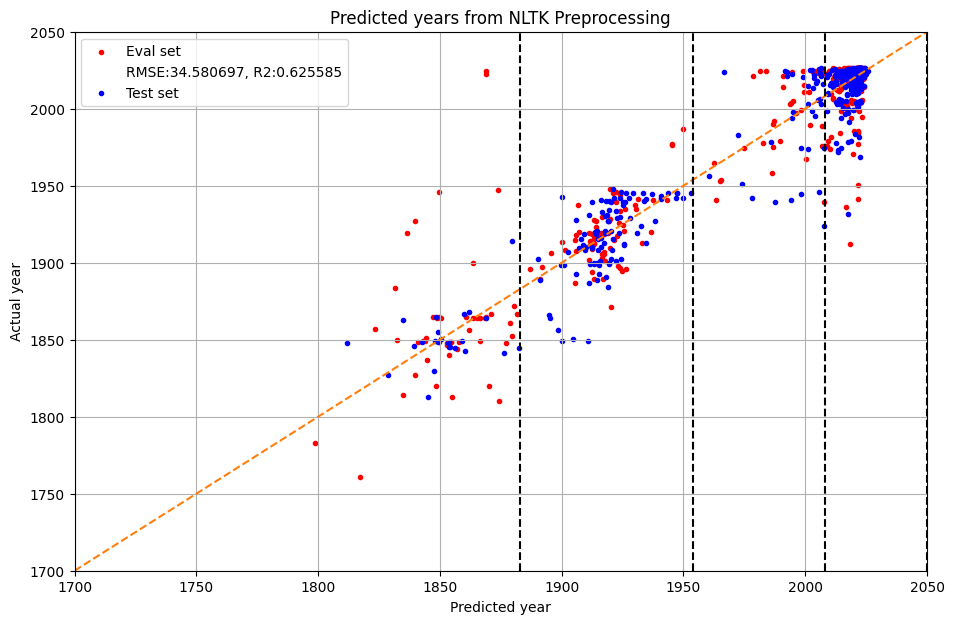

In [55]:

plt.figure(figsize = (11,7))

#plt.plot(y_pred,y_test, '.', label = 'Eval set')
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
#plt.plot(y_train_pred, y_train, '.', alpha = 0.3, c = 'orange', label = 'Train set')
#plt.errorbar(y_pred, y_eval, xerr =rmse, fmt = ',', c= 'lightblue', label = 'Eval set')
#plt.scatter(y_pred,y_eval, c = c_cluster)
plt.scatter(y_pred,y_eval, marker = '.', c = 'red', label = 'Eval set')
plt.plot([],[], ' ', label = f'RMSE:{rmse:3f}, R2:{r2:3f}')

plt.scatter(y_test_pred, y_test, marker = '.',c = 'blue', label = 'Test set')

plt.plot([1700,2050],[1700,2050], '--')
plt.xlabel('Predicted year')
plt.ylabel('Actual year')
plt.xlim(1700,2050)
plt.ylim(1700,2050)

for i in Intervals_xgb:
    plt.axvline(i, linestyle = '--', c = 'black')

#plt.plot([],[], ' ', label = f'RMSE:{rmse:3f}, R2:{r2:3f}')
plt.grid()
plt.title('Predicted years from NLTK Preprocessing')
plt.legend()


<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Geniet\AppData\Local\Temp\ipykernel_10488\708554812.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.2f}, $\sigma$: {scale:.2f}')
C:\Users\Geniet\AppData\Local\Temp\ipykernel_10488\708554812.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.2f}, $\sigma$: {scale:.2f}')


Sum of observed counts: 0.6870494092264618
Sum of expected counts: 690.1589334101869
Fitted t-distribution: pdf = 0.69, loc = -6.38, scale = 1.66
Chi-square statistic: 0.47
P-value: 1.0000


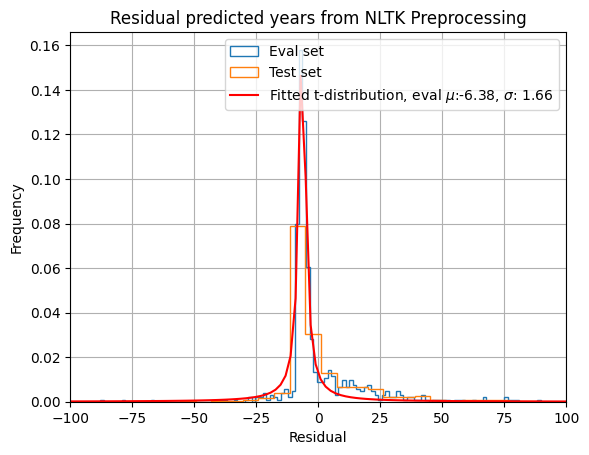

In [524]:
#def Gauss(x,a,b,c):
#    return( a*np.exp(-( (x-b)**2) / (2*c**2) ) )



#plt.plot(abs(y_train_pred -y_train), '.', alpha = 0.3, c = 'orange', label = 'Train set')
n_eval, bins_eval, patches_eval = plt.hist(y_pred-y_eval, bins = 200, density = True, histtype = 'step', label = 'Eval set')
n_test, bins_test, patches_test = plt.hist(y_pred_test-y_test, density = True, bins = 500, histtype = 'step', label = 'Test set')

#par_eval, cov_eval = curve_fit(Gauss, (bins_eval[:-1] + bins_eval[1:] )/2 , n_eval, p0 = [0.08, 0, 4])
#par_test, cov_test = curve_fit(Gauss, (bins_test[:-1] + bins_test[1:] )/2, n_test, p0 = [0.08, 0, 5])

pdf, loc, scale = t.fit(y_pred-y_eval)

pdf_values = t.pdf((bins_eval[:-1] + bins_eval[1:] )/2, pdf, loc, scale)
bin_width_eval = bins_eval[1] - bins_eval[0]
expected_counts = pdf_values * len(y_pred-y_eval) * bin_width_eval

print("Sum of observed counts:", np.sum(n_eval))
print("Sum of expected counts:", np.sum(expected_counts))
expected_counts = pdf_values * len(y_pred-y_eval) * bin_width_eval *(np.sum(n_eval)/np.sum(expected_counts))

# Step 5: Perform chi-square test
chi2_stat, p_value = chisquare(n_eval, f_exp=expected_counts)

print(f"Fitted t-distribution: pdf = {pdf:.2f}, loc = {loc:.2f}, scale = {scale:.2f}")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

#print(len(n_eval),'\n', len(bins_eval[:-1]), '\n', patches_eval )
X_fit = np.linspace(-100,100, 100)
#plt.plot(X_fit, Gauss(X_fit, *par_eval), label = 'eval fit')
#plt.plot(X_fit, Gauss(X_fit, *par_test), label = 'test fit')
plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.2f}, $\sigma$: {scale:.2f}')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.xlim(-100, 100)

plt.grid()
plt.title('Residual predicted years from NLTK Preprocessing')
plt.legend()

#print(par_eval, '\n', par_test)

#obs_eval = Gauss((bins_eval[:-1] + bins_eval[1:] )/2, *par_eval)

#chi2_stat, p_value = chisquare(obs_eval, f_exp=n_eval)
#print(chi2_stat, p_value)

In [357]:
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators": randint(180, 220),          # Number of boosting rounds
    "max_depth": randint(8, 12),                # Tree depth
    "learning_rate": uniform(0.24, 0.06),        # Step size shrinkage
    "subsample": uniform(0.9, 0.1),             # Fraction of samples per tree
    "colsample_bytree": uniform(0.5, 0.4),      # Fraction of features per tree
    "gamma": uniform(0.6, 0.2),                   # Minimum loss reduction for split
    #"min_child_weight": randint(1, 4),         # Minimum sum of instance weight (hessian) needed in a child
    "reg_alpha": uniform(0.6, 0.4),                 # L1 regularization
    "reg_lambda": uniform(0.8, 0.2),                # L2 regularization
}

# Initialize XGBRegressor with early stopping
xgb_model = xgb.XGBRegressor(
    tree_method ='hist',
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=20,  # Stop if no improvement for 30 rounds
    eval_metric="rmse",         # Metric for early stopping
    n_jobs=1,                  # -1 to use all CPU cores
)

# Randomized search with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,                  # Number of parameter settings sampled
    cv=3,                       # 3-fold cross-validation
    scoring="neg_root_mean_squared_error",  # Minimize RMSE
    verbose=2,
    n_jobs= 1,                  # Parallel jobs
    random_state=42,
)

# Fit the model (with early stopping on validation set)
random_search.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_eval, y_eval)],  # Early stopping uses validation set
)

# Best parameters and model
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[0]	validation_0-rmse:97.78408	validation_1-rmse:42.43290
[1]	validation_0-rmse:93.00756	validation_1-rmse:33.57208
[2]	validation_0-rmse:90.76547	validation_1-rmse:27.14092
[3]	validation_0-rmse:88.59805	validation_1-rmse:24.99191
[4]	validation_0-rmse:87.78186	validation_1-rmse:22.71095
[5]	validation_0-rmse:87.51045	validation_1-rmse:21.26865
[6]	validation_0-rmse:87.55431	validation_1-rmse:20.33698
[7]	validation_0-rmse:87.78459	validation_1-rmse:19.91345
[8]	validation_0-rmse:88.07632	validation_1-rmse:19.68556
[9]	validation_0-rmse:87.89293	validation_1-rmse:19.70636
[10]	validation_0-rmse:88.19489	validation_1-rmse:19.65653
[11]	validation_0-rmse:88.10580	validation_1-rmse:20.01546
[12]	validation_0-rmse:88.05927	validation_1-rmse:19.97908
[13]	validation_0-rmse:87.99451	validation_1-rmse:19.95684
[14]	validation_0-rmse:88.21896	validation_1-rmse:19.90949
[15]	validation_0-rmse:88.43317	validation_1-rmse:19.88908
[16]

In [359]:
best_model.save_model('best_model_LIX.json')

Best parameters found:  {'gamma': np.float64(0.6348732858009982), 'learning_rate': np.float64(0.28145626428614795), 'max_depth': 11, 'n_estimators': 218, 'reg_alpha': np.float64(0.9810189966210203), 'reg_lambda': np.float64(0.8275041888291987), 'subsample': np.float64(0.9341066351050259)}

<h1> Loading best model</h1>

In [526]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

best_model = xgb.XGBRegressor(
    tree_method ='hist',
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=50,  # Stop if no improvement for 30 rounds
    eval_metric="rmse",         # Metric for early stopping
    n_jobs=1,                  # -1 to use all CPU cores
)

best_model.load_model('best_model_LIX.json')

RMSE: 19.050
R²: 0.886
RMSE: 97.653
R²: 0.185


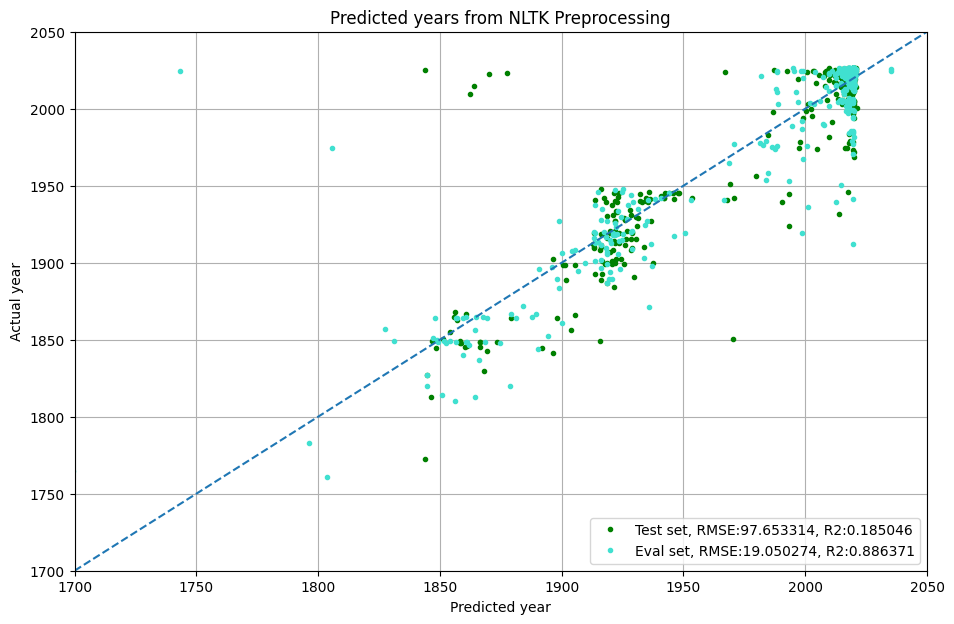

In [413]:
plt.figure(figsize = (11,7))

y_pred_best = best_model.predict(X_eval)
y_test_best = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_eval, y_pred_best))
r2 = r2_score(y_eval, y_pred_best)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_best))
r2_test = r2_score(y_test, y_test_best)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')
print(f'RMSE: {rmse_test:.3f}')
print(f'R²: {r2_test:.3f}')

lim = np.array([[1700,1700],[2050,2050]])
#plt.plot(y_pred,y_test, '.', label = 'Eval set')
y_train_pred_best = best_model.predict(X_train)
#plt.plot(y_train_pred_best, y_train, '.', alpha = 1, c = 'orange', label = 'Train set')
plt.plot(y_test_best, y_test, '.', alpha = 1, c = 'green', label = f'Test set, RMSE:{rmse_test:3f}, R2:{r2_test:3f}')
#plt.scatter(y_pred_best,y_test, c = c_cluster)
plt.plot(y_pred_best,y_eval, '.', c= 'turquoise', label = f'Eval set, RMSE:{rmse:3f}, R2:{r2:3f}')

plt.plot([1700,2050],[1700,2050], '--')
plt.xlabel('Predicted year')
plt.ylabel('Actual year')
plt.xlim(1700,2050)
plt.ylim(1700,2050)

#plt.plot([],[], ' ', label = f'RMSE:{rmse:3f}, R2:{r2:3f}')
plt.grid()
plt.title('Predicted years from NLTK Preprocessing')
plt.legend()

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Geniet\AppData\Local\Temp\ipykernel_10488\772927653.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.3f}, $\sigma$: {scale:.3f}')
C:\Users\Geniet\AppData\Local\Temp\ipykernel_10488\772927653.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, eval $\mu$:{loc:.3f}, $\sigma$: {scale:.3f}')


Sum of observed counts: 0.5063890181928491
Sum of expected counts: 700.5616006807766
Fitted t-distribution: pdf = 0.83, loc = -4.12, scale = 2.01
Chi-square statistic: 0.25
P-value: 1.0000


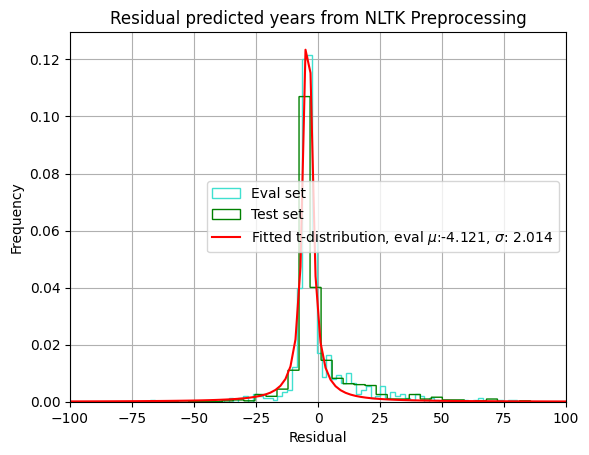

In [415]:
#plt.plot(abs(y_train_pred -y_train), '.', alpha = 0.3, c = 'orange', label = 'Train set')
n_eval, bins_eval, patches_eval = plt.hist(y_pred_best-y_eval,
                                           color= 'turquoise',
                                           bins = 200, density = True,
                                           histtype = 'step',
                                           label = 'Eval set')
plt.hist(y_test_best - y_test, 
         color = 'green',
         bins = 700,
         density = True,
         histtype = 'step', 
         label ='Test set' )

#par_eval, cov_eval = curve_fit(Gauss, (bins_eval[:-1] + bins_eval[1:] )/2 , n_eval, p0 = [0.08, 0, 4])
#par_test, cov_test = curve_fit(Gauss, (bins_test[:-1] + bins_test[1:] )/2, n_test, p0 = [0.08, 0, 5])

pdf, loc, scale = t.fit(y_pred_best-y_eval)

pdf_values = t.pdf((bins_eval[:-1] + bins_eval[1:] )/2, pdf, loc, scale)
bin_width_eval = bins_eval[1] - bins_eval[0]
expected_counts = pdf_values * len(y_pred_best - y_eval) * bin_width_eval

print("Sum of observed counts:", np.sum(n_eval))
print("Sum of expected counts:", np.sum(expected_counts))
expected_counts = pdf_values * len(y_pred_best - y_eval) * bin_width_eval * np.sum(n_eval)/np.sum(expected_counts)

# Step 5: Perform chi-square test
chi2_stat, p_value = chisquare(n_eval, f_exp=expected_counts)

print(f"Fitted t-distribution: pdf = {pdf:.2f}, loc = {loc:.2f}, scale = {scale:.2f}")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

#print(len(n_eval),'\n', len(bins_eval[:-1]), '\n', patches_eval )
X_fit = np.linspace(-100,100, 100)

plt.plot(X_fit, t.pdf(X_fit, pdf, loc, scale), 'r-', label=f'Fitted t-distribution, Eval $\mu$:{loc:.3f}, $\sigma$: {scale:.3f}')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.xlim(-100, 100)

plt.grid()
plt.title('Residual predicted years from NLTK Preprocessing')
plt.legend()

#print(par_eval, '\n', par_test)

#obs_eval = Gauss((bins_eval[:-1] + bins_eval[1:] )/2, *par_eval)

#chi2_stat, p_value = chisquare(obs_eval, f_exp=n_eval)
#print(chi2_stat, p_value)